k = (8.174 ± 0.076) см^2
b = 4.803 см^2
n_o - n_e = 0.099 ± 0.008


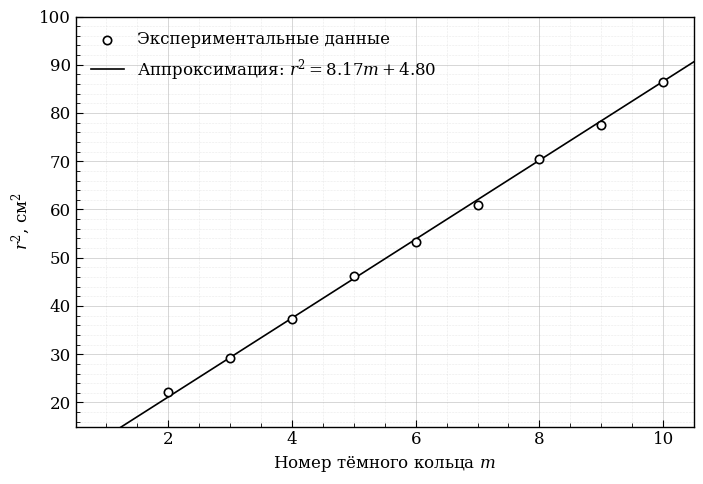

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------- Экспериментальные данные --------------------

# Радиусы тёмных колец, см
r = np.array([3.6, 4.7, 5.4, 6.1, 6.8, 7.3, 7.8, 8.4, 8.8, 9.3, 9.8])
# Номера тёмных колец
m = np.arange(1, len(r)+1)

# -------------------- Параметры установки --------------------
L = 80.0           # расстояние от середины кристалла до экрана, см
sigma_L = 3.0     # погрешность измерения L, см

l = 2.6           # длина кристалла, см
lambda_ = 0.63e-4 # длина волны лазера, см
n_o = 2.29        # обыкновенный показатель преломления

# -------------------- Обработка данных --------------------
r2 = r**2

# Линейная аппроксимация r^2 = k m + b
k, b = np.polyfit(m, r2, 1)
r2_fit = k * m + b

# Оценка случайной погрешности коэффициента наклона
n = len(m)
residuals = r2 - r2_fit
Sxx = np.sum((m - np.mean(m))**2)
s2 = np.sum(residuals**2) / (n - 2)
sigma_k = np.sqrt(s2 / Sxx)

# Расчёт двулучепреломления
delta_n = (lambda_ / l) * (n_o * L)**2 / k

# Погрешность результата:
# delta_n зависит от L как L^2, а от k как 1/k
sigma_delta_n = delta_n * np.sqrt((2 * sigma_L / L)**2 + (sigma_k / k)**2)

print(f"k = ({k:.3f} ± {sigma_k:.3f}) см^2")
print(f"b = {b:.3f} см^2")
print(f"n_o - n_e = {delta_n:.3f} ± {sigma_delta_n:.3f}")

# -------------------- График в стиле для отчёта --------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "legend.frameon": False,
    "mathtext.fontset": "dejavuserif",
})

fig, ax = plt.subplots(figsize=(7.2, 5.0))

# Экспериментальные точки
ax.scatter(
    m,
    r2,
    marker="o",
    facecolors="white",
    edgecolors="black",
    linewidths=1.2,
    label="Экспериментальные данные",
    zorder=3
)

# Аппроксимирующая прямая
m_line = np.linspace(m.min(), m.max(), 200)
ax.plot(
    m_line,
    k * m_line + b,
    linestyle="-",
    linewidth=1.2,
    color="black",
    label=rf"Аппроксимация: $r^2 = {k:.2f}m + {b:.2f}$"
)

# Подписи осей
ax.set_xlabel(r"Номер тёмного кольца $m$")
ax.set_ylabel(r"$r^2$, см$^2$")

# Сетка и деления
ax.minorticks_on()
ax.grid(which="major", linewidth=0.6, linestyle="-", alpha=0.6)
ax.grid(which="minor", linewidth=0.4, linestyle=":", alpha=0.5)

# Границы графика
ax.set_xlim(0.5, 10.5)
ax.set_ylim(15, 100)

# Легенда
ax.legend(loc="upper left")

fig.tight_layout()

# Сохранение графика
output_path = Path("pockels_r2_fit_gost.pdf")
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

    2phi1, deg  phi1, deg  psi_o, deg  phi2_o, deg    n_o  psi_e, deg  \
0         30.0       15.0        32.0         56.0  1.657        20.5   
1         40.0       20.0        29.5         48.5  1.648        20.0   
2         50.0       25.0        27.5         41.5  1.631        19.0   
3         60.0       30.0        26.5         35.5  1.619        19.0   
4         70.0       35.0        27.0         31.0  1.631        20.0   
5         80.0       40.0        27.5         26.5  1.634        21.0   
6         90.0       45.0        29.0         23.0  1.653        22.0   
7        100.0       50.0        30.0         19.0  1.652        23.5   
8        110.0       55.0        31.5         15.5  1.653        25.5   
9        120.0       60.0        34.0         13.0  1.669        28.0   
10       130.0       65.0        36.5         10.5  1.675        30.5   
11       140.0       70.0        40.0          9.0  1.694        34.0   

    phi2_e, deg    n_e  
0          44.5  1.457  


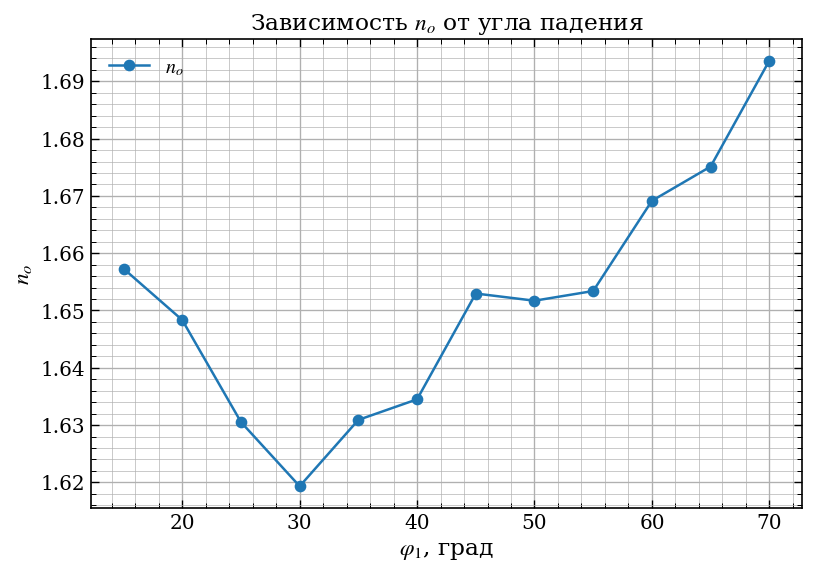

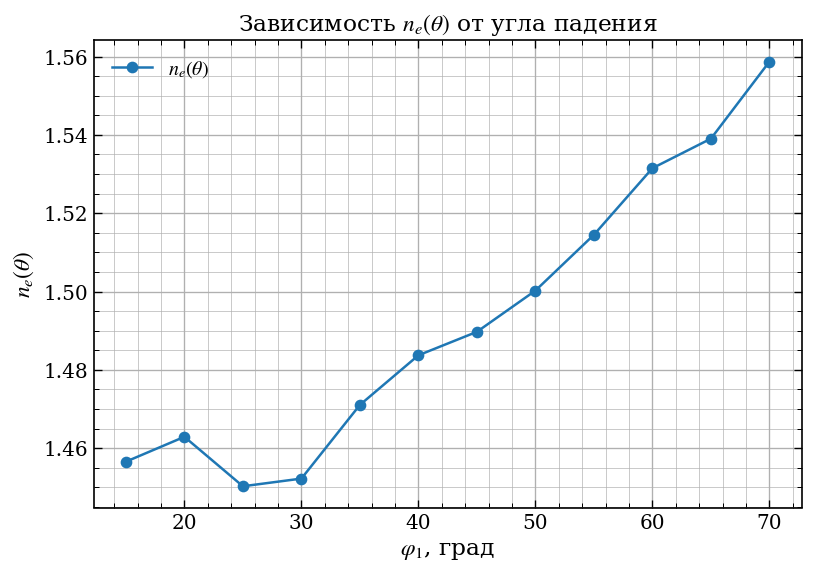

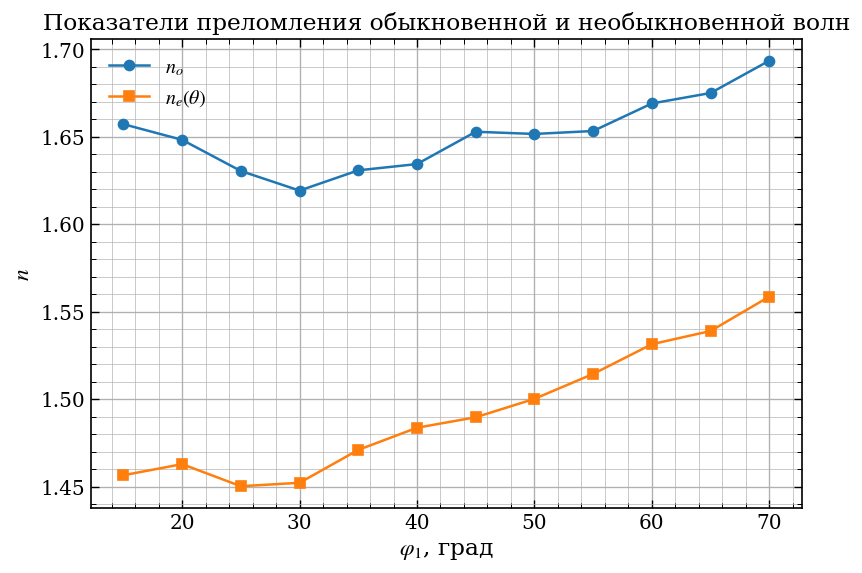

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------- Исходные данные --------------------

A = 39.0  # угол призмы, град

# Общая область, где есть данные для обеих волн
two_phi1 = np.array([30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140], dtype=float)

# Координаты лучей на лимбе, град
alpha_o = np.array([212, 209.5, 207.5, 206.5, 207, 207.5, 209, 210, 211.5, 214, 216.5, 220], dtype=float)

# В исходных данных для необыкновенной волны было одно лишнее первое значение.
# Его не используем, чтобы совместить таблицы по одинаковым углам падения.
alpha_e = np.array([200.5, 200, 199, 199, 200, 201, 202, 203.5, 205.5, 208, 210.5, 214], dtype=float)
# alpha_e = np.array([100.5, 108.5, 120, 141.5, 152.5, 162.5, 172, 181.5, 191, 199, 207, 214], dtype=float)

# -------------------- Функции --------------------

def sind(x):
    """Синус угла в градусах."""
    return np.sin(np.deg2rad(x))

def cosd(x):
    """Косинус угла в градусах."""
    return np.cos(np.deg2rad(x))

def refractive_index(phi1, phi2, A):
    """
    Расчёт показателя преломления призмы по углам phi1, phi2 и A.
    Все углы задаются в градусах.
    """
    numerator = np.sqrt(
        sind(phi1)**2
        + sind(phi2)**2
        + 2 * sind(phi1) * sind(phi2) * cosd(A)
    )
    return numerator / sind(A)

# -------------------- Расчёт углов --------------------

phi1 = two_phi1 / 2

psi_o = alpha_o - 180
psi_e = alpha_e - 180

phi2_o = A + psi_o - phi1
phi2_e = A + psi_e - phi1

# -------------------- Расчёт показателей преломления --------------------

n_o = refractive_index(phi1, phi2_o, A)
n_e = refractive_index(phi1, phi2_e, A)

# -------------------- Таблица --------------------

df = pd.DataFrame({
    r"2phi1, deg": two_phi1,
    r"phi1, deg": phi1,
    r"psi_o, deg": psi_o,
    r"phi2_o, deg": phi2_o,
    r"n_o": n_o,
    r"psi_e, deg": psi_e,
    r"phi2_e, deg": phi2_e,
    r"n_e": n_e,
})

print(df.round(3))

# Сохранение таблицы
df.to_csv("table_471.csv", index=False)

# -------------------- Оформление графиков --------------------

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 120,
})

def setup_axes(ax):
    ax.grid(True, which="major", linewidth=0.8)
    ax.grid(True, which="minor", linewidth=0.4)
    ax.minorticks_on()
    ax.tick_params(direction="in", which="both", top=True, right=True)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

# -------------------- График n_o(phi1) --------------------

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(phi1, n_o, marker="o", linewidth=1.5, label=r"$n_o$")
ax.set_xlabel(r"$\varphi_1$, град")
ax.set_ylabel(r"$n_o$")
ax.set_title(r"Зависимость $n_o$ от угла падения")
ax.legend()
setup_axes(ax)

fig.tight_layout()
fig.savefig("n_o_from_phi1.png", dpi=300)
plt.show()

# -------------------- График n_e(phi1) --------------------

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(phi1, n_e, marker="o", linewidth=1.5, label=r"$n_e(\theta)$")
ax.set_xlabel(r"$\varphi_1$, град")
ax.set_ylabel(r"$n_e(\theta)$")
ax.set_title(r"Зависимость $n_e(\theta)$ от угла падения")
ax.legend()
setup_axes(ax)

fig.tight_layout()
fig.savefig("n_e_from_phi1.png", dpi=300)

# -------------------- Совместный график --------------------

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(phi1, n_o, marker="o", linewidth=1.5, label=r"$n_o$")
ax.plot(phi1, n_e, marker="s", linewidth=1.5, label=r"$n_e(\theta)$")

ax.set_xlabel(r"$\varphi_1$, град")
ax.set_ylabel(r"$n$")
ax.set_title(r"Показатели преломления обыкновенной и необыкновенной волн")
ax.legend()
setup_axes(ax)

fig.tight_layout()
fig.savefig("n_o_n_e_from_phi1.pdf", dpi=300)
plt.show()

,"2phi1, deg","phi1, deg","psi_o, deg","phi2_o, deg",n_o,"psi_e, deg","phi2_e, deg",n_e,cos2_theta_o,cos2_theta_e
0,30.0,15.0,32.0,56.0,1.6573,20.5,44.5,1.4566,0.0244,0.0316
1,40.0,20.0,29.5,48.5,1.6483,20.0,39.0,1.4629,0.0431,0.0547
2,50.0,25.0,27.5,41.5,1.6305,19.0,33.0,1.4503,0.0672,0.0849
3,60.0,30.0,26.5,35.5,1.6193,19.0,28.0,1.4522,0.0953,0.1185
4,70.0,35.0,27.0,31.0,1.6309,20.0,24.0,1.4710,0.1237,0.1520
5,80.0,40.0,27.5,26.5,1.6345,21.0,20.0,1.4837,0.1547,0.1877
6,90.0,45.0,29.0,23.0,1.6530,22.0,16.0,1.4897,0.1830,0.2253
7,100.0,50.0,30.0,19.0,1.6517,23.5,12.5,1.5002,0.2151,0.2607
8,110.0,55.0,31.5,15.5,1.6534,25.5,9.5,1.5145,0.2455,0.2926
9,120.0,60.0,34.0,13.0,1.6691,28.0,7.0,1.5315,0.2692,0.3198


n_o = 1.6514 ± 0.0211
n_e(cos^2(theta)) = 0.3015 * cos^2(theta) + 1.4313
n_e при cos^2(theta)=0: 1.4313
n_e при cos^2(theta)=1: 1.7328


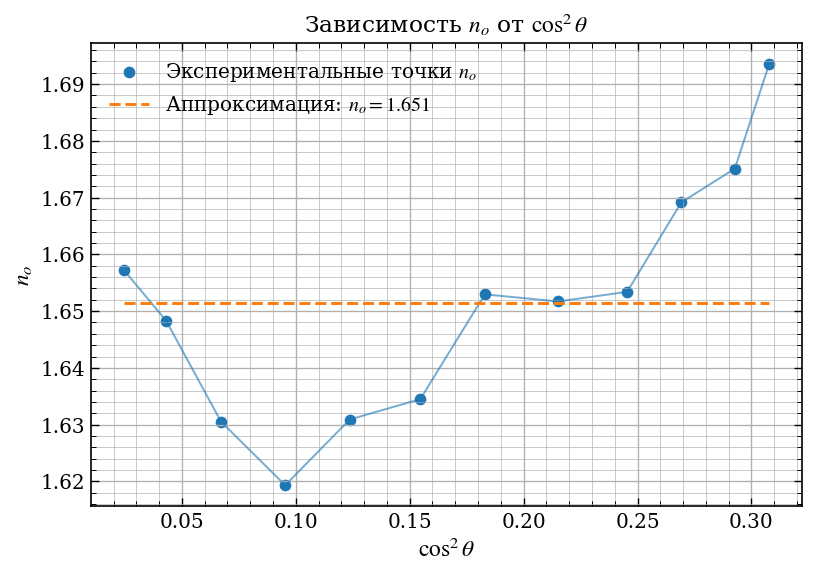

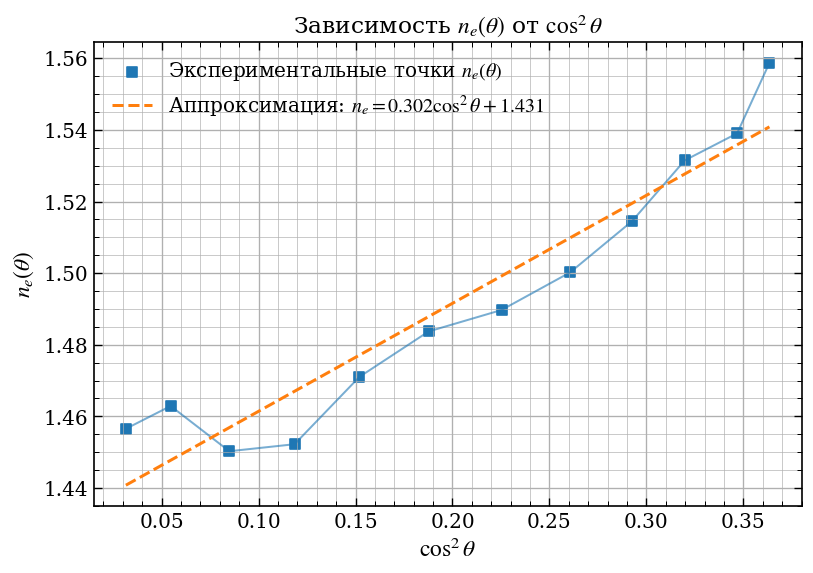

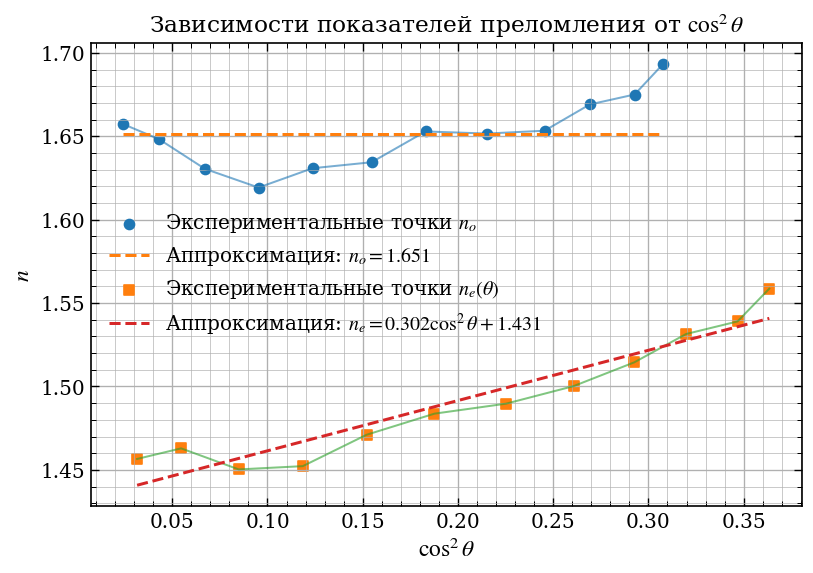

In [20]:
# -------------------- Графики n_o и n_e от cos^2(theta) --------------------

# Для каждой волны считаем cos(theta) = sin(phi1) / n
cos_theta_o = sind(phi1) / n_o
cos_theta_e = sind(phi1) / n_e

cos2_theta_o = cos_theta_o**2
cos2_theta_e = cos_theta_e**2

# Добавим эти значения в таблицу
df["cos2_theta_o"] = cos2_theta_o
df["cos2_theta_e"] = cos2_theta_e

display(df.round(4))

# -------------------- Аппроксимации --------------------

# n_o аппроксимируем константой
n_o_const = np.mean(n_o)
n_o_std = np.std(n_o, ddof=1)

# n_e аппроксимируем линейной функцией n_e = k * cos^2(theta) + b
k_e, b_e = np.polyfit(cos2_theta_e, n_e, deg=1)

# Для гладких линий аппроксимации
x_o_fit = np.linspace(np.min(cos2_theta_o), np.max(cos2_theta_o), 200)
y_o_fit = np.full_like(x_o_fit, n_o_const)

x_e_fit = np.linspace(np.min(cos2_theta_e), np.max(cos2_theta_e), 200)
y_e_fit = k_e * x_e_fit + b_e

print(f"n_o = {n_o_const:.4f} ± {n_o_std:.4f}")
print(f"n_e(cos^2(theta)) = {k_e:.4f} * cos^2(theta) + {b_e:.4f}")
print(f"n_e при cos^2(theta)=0: {b_e:.4f}")
print(f"n_e при cos^2(theta)=1: {k_e + b_e:.4f}")

# -------------------- График n_o(cos^2 theta) --------------------

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(cos2_theta_o, n_o, marker="o", label=r"Экспериментальные точки $n_o$")
ax.plot(cos2_theta_o, n_o, linewidth=1.2, alpha=0.6)

ax.plot(
    x_o_fit,
    y_o_fit,
    linestyle="--",
    linewidth=1.8,
    label=rf"Аппроксимация: $n_o = {n_o_const:.3f}$"
)

ax.set_xlabel(r"$\cos^2 \theta$")
ax.set_ylabel(r"$n_o$")
ax.set_title(r"Зависимость $n_o$ от $\cos^2\theta$")
ax.legend()

setup_axes(ax)

fig.tight_layout()
fig.savefig("n_o_from_cos2theta.pdf", dpi=300)
plt.show()


# -------------------- График n_e(cos^2 theta) --------------------

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(cos2_theta_e, n_e, marker="s", label=r"Экспериментальные точки $n_e(\theta)$")
ax.plot(cos2_theta_e, n_e, linewidth=1.2, alpha=0.6)

ax.plot(
    x_e_fit,
    y_e_fit,
    linestyle="--",
    linewidth=1.8,
    label=rf"Аппроксимация: $n_e = {k_e:.3f}\cos^2\theta + {b_e:.3f}$"
)

ax.set_xlabel(r"$\cos^2 \theta$")
ax.set_ylabel(r"$n_e(\theta)$")
ax.set_title(r"Зависимость $n_e(\theta)$ от $\cos^2\theta$")
ax.legend()

setup_axes(ax)

fig.tight_layout()
fig.savefig("n_e_from_cos2theta.pdf", dpi=300)
plt.show()


# -------------------- Совместный график --------------------

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(cos2_theta_o, n_o, marker="o", label=r"Экспериментальные точки $n_o$")
ax.plot(cos2_theta_o, n_o, linewidth=1.2, alpha=0.6)

ax.plot(
    x_o_fit,
    y_o_fit,
    linestyle="--",
    linewidth=1.8,
    label=rf"Аппроксимация: $n_o = {n_o_const:.3f}$"
)

ax.scatter(cos2_theta_e, n_e, marker="s", label=r"Экспериментальные точки $n_e(\theta)$")
ax.plot(cos2_theta_e, n_e, linewidth=1.2, alpha=0.6)

ax.plot(
    x_e_fit,
    y_e_fit,
    linestyle="--",
    linewidth=1.8,
    label=rf"Аппроксимация: $n_e = {k_e:.3f}\cos^2\theta + {b_e:.3f}$"
)

ax.set_xlabel(r"$\cos^2 \theta$")
ax.set_ylabel(r"$n$")
ax.set_title(r"Зависимости показателей преломления от $\cos^2\theta$")
ax.legend()

setup_axes(ax)

fig.tight_layout()
fig.savefig("n_o_n_e_from_cos2theta.pdf", dpi=300)
plt.show()

k = dn/dlambda = -1.274e-04 1/нм
c = 1.68929
dn/dlambda = -1.274e+03 1/см


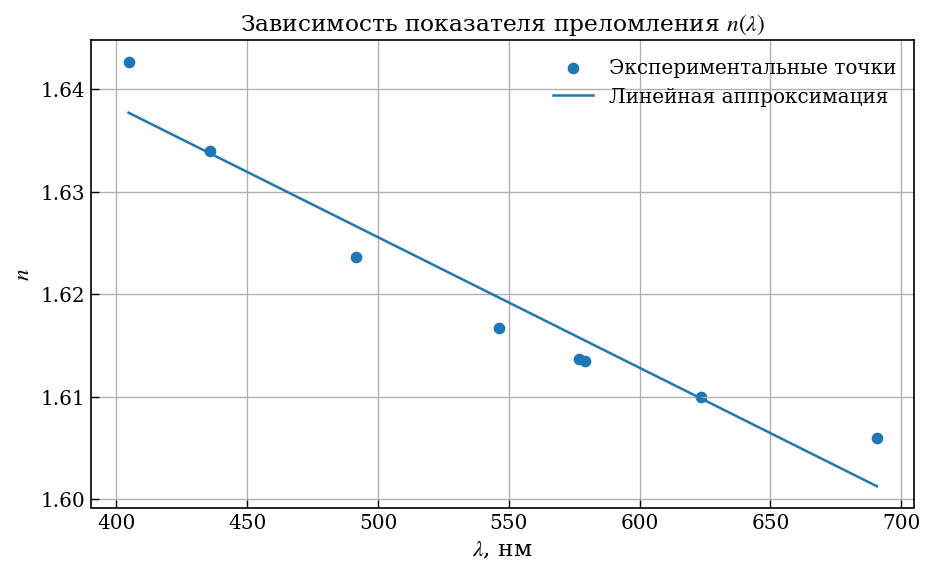

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Данные: длина волны lambda в нм и показатель преломления n
lambda_nm = np.array([690.7, 623.4, 579.1, 577.0, 546.1, 491.6, 435.8, 404.7])
n = np.array([1.6060, 1.6100, 1.6135, 1.6137, 1.6167, 1.6236, 1.6340, 1.6427])

# Линейная аппроксимация: n(lambda) = k * lambda + c
k, c = np.polyfit(lambda_nm, n, deg=1)

# Точки для построения аппроксимирующей прямой
lambda_fit = np.linspace(lambda_nm.min(), lambda_nm.max(), 300)
n_fit = k * lambda_fit + c

print(f"k = dn/dlambda = {k:.3e} 1/нм")
print(f"c = {c:.5f}")
print(f"dn/dlambda = {k / 1e-7:.3e} 1/см")

# Построение графика
plt.figure(figsize=(8, 5))

plt.scatter(lambda_nm, n, label="Экспериментальные точки")
plt.plot(lambda_fit, n_fit, label="Линейная аппроксимация")

plt.xlabel(r"$\lambda$, нм")
plt.ylabel(r"$n$")
plt.title(r"Зависимость показателя преломления $n(\lambda)$")

plt.grid(True)
plt.legend()
plt.tight_layout()

# Сохранение графика для LaTeX
plt.savefig("graph_n_lambda.pdf", dpi=300)

plt.show()